Connected to .venv (Python 3.11.0)

Hourly power: 87664 rows, 1.4% missing
Daily profiles: 3588 days
Mode D feature matrix: (3558, 37)
PCA: 37 → 22 dims  (95.4% variance explained)

--- L1 K selection (Mode D, per-day norm) ---


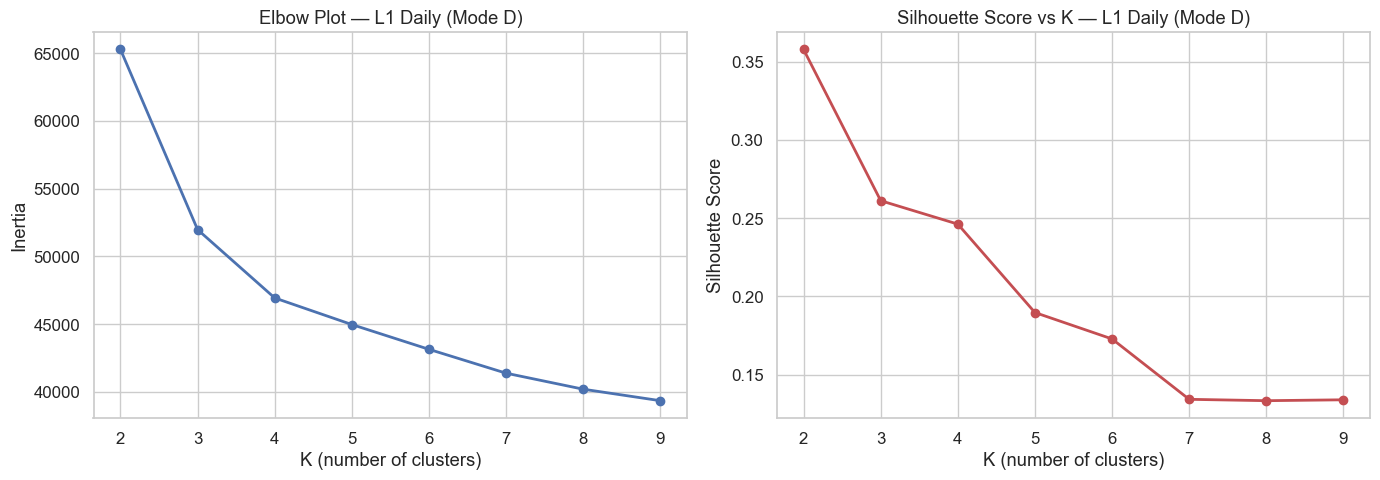


  L1 Daily K=4 — K=4
  Silhouette score:       0.2462
  Calinski-Harabasz:      1318.7
  Davies-Bouldin:         1.5660

  Per-cluster breakdown:
   Cluster   Size       %  Silhouette
  -----------------------------------
         0    483   13.6%     0.0708
         1    621   17.5%     0.2836
         2   1226   34.5%     0.2973
         3   1228   34.5%     0.2452



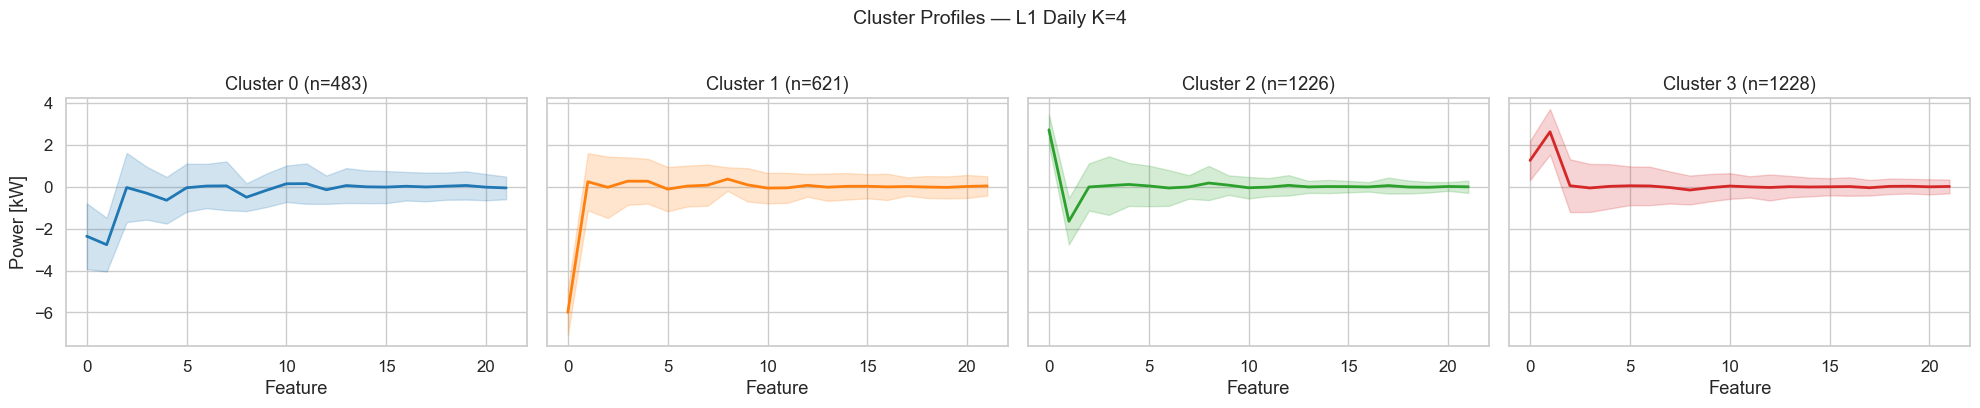

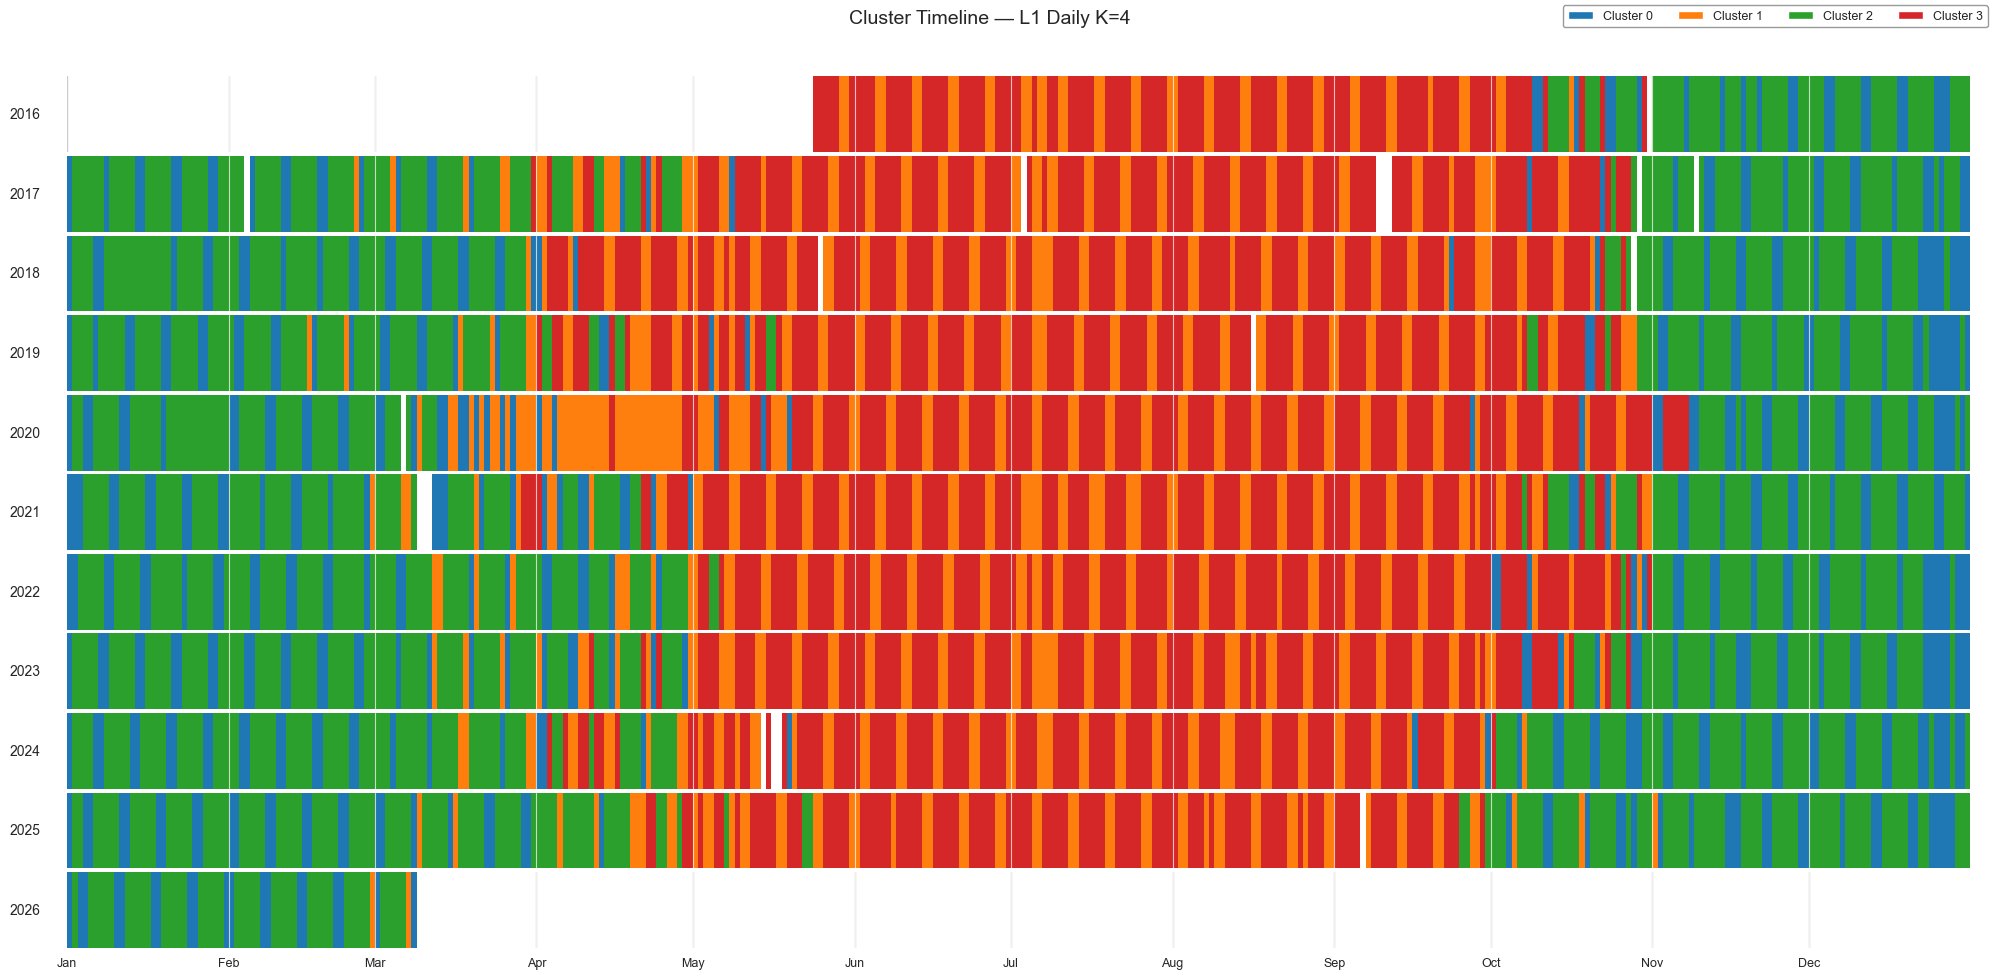

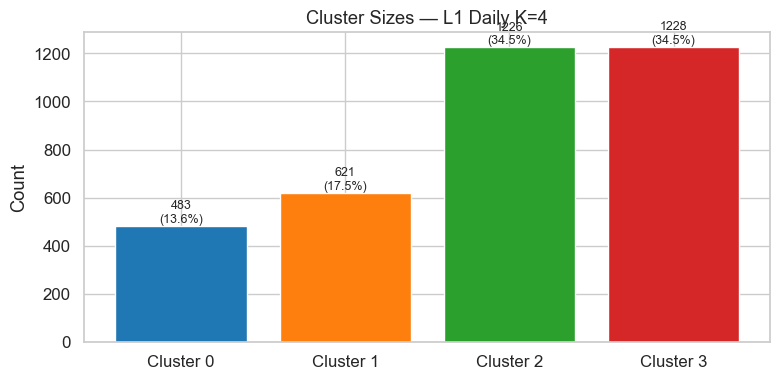

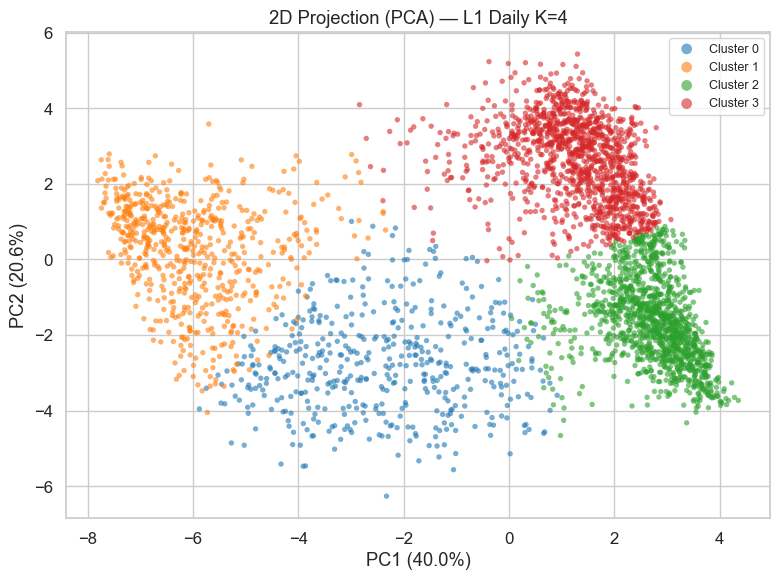


--- Building L2 feature matrices ---
  W= 7d: 3552 observations, 5 features (4 histogram bins + 1 power mean)
  W=14d: 3545 observations, 5 features (4 histogram bins + 1 power mean)
  W=28d: 3531 observations, 5 features (4 histogram bins + 1 power mean)

--- L2 K selection (W=7d) ---


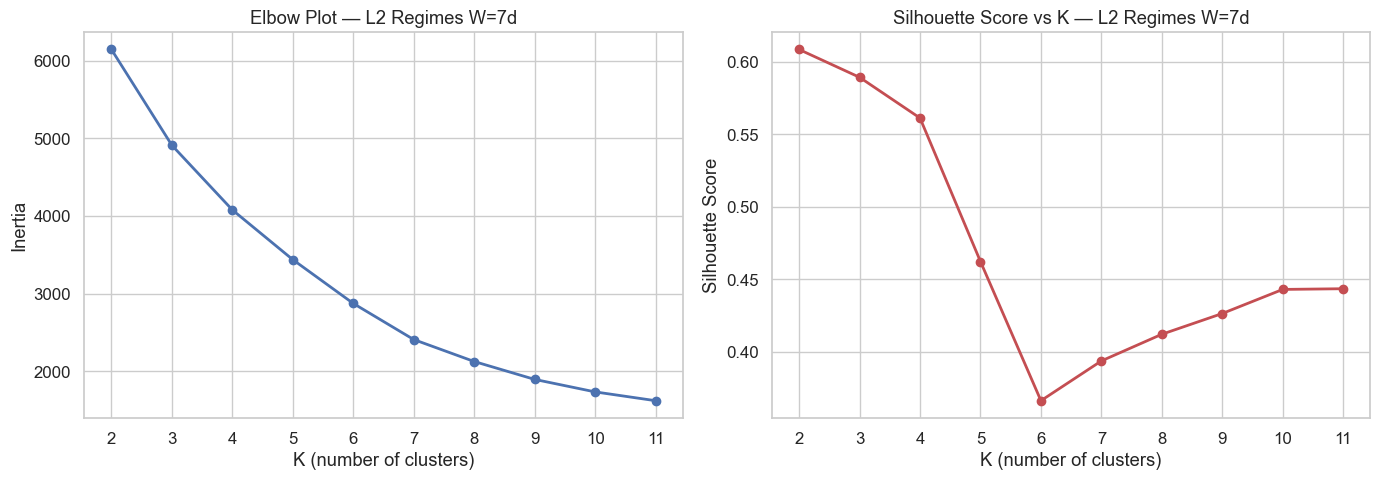


--- L2 K selection (W=14d) ---


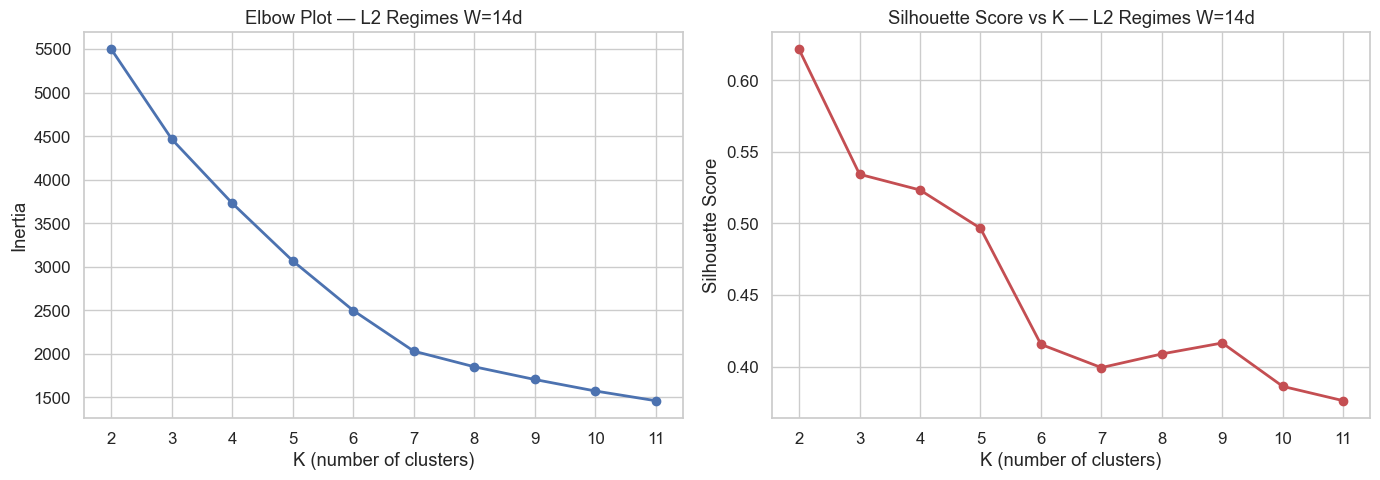


--- L2 K selection (W=28d) ---


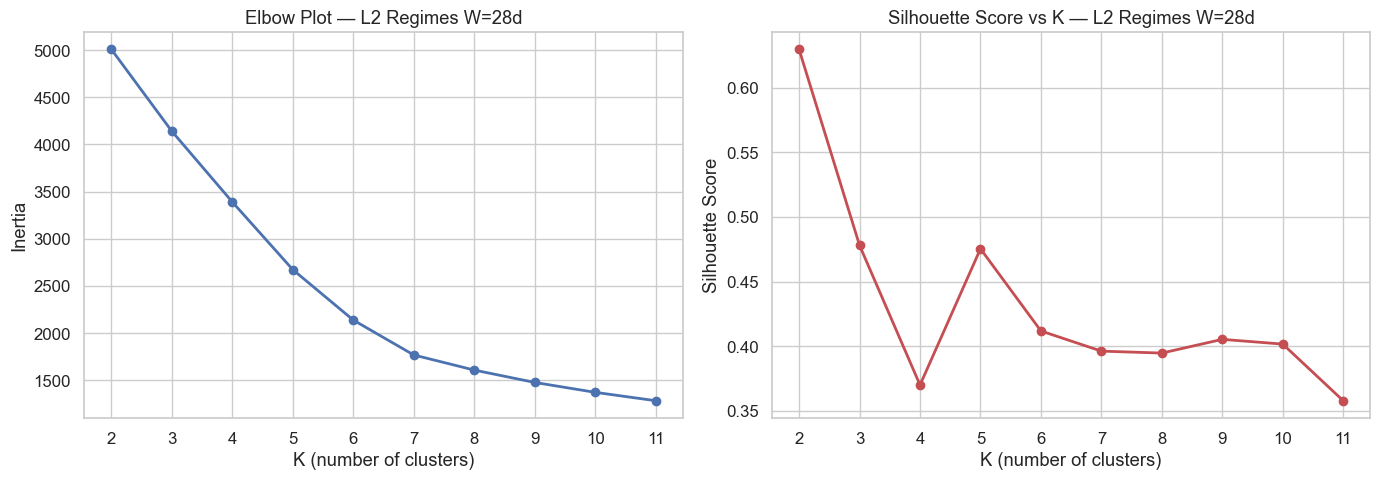


  L2 Regimes K=5 W=14d — K=5
  Silhouette score:       0.4966
  Calinski-Harabasz:      4230.5
  Davies-Bouldin:         0.8519

  Per-cluster breakdown:
   Cluster   Size       %  Silhouette
  -----------------------------------
         0    393   11.1%     0.2267
         1   1665   47.0%     0.6039
         2   1145   32.3%     0.4865
         3     59    1.7%     0.4540
         4    283    8.0%     0.2903



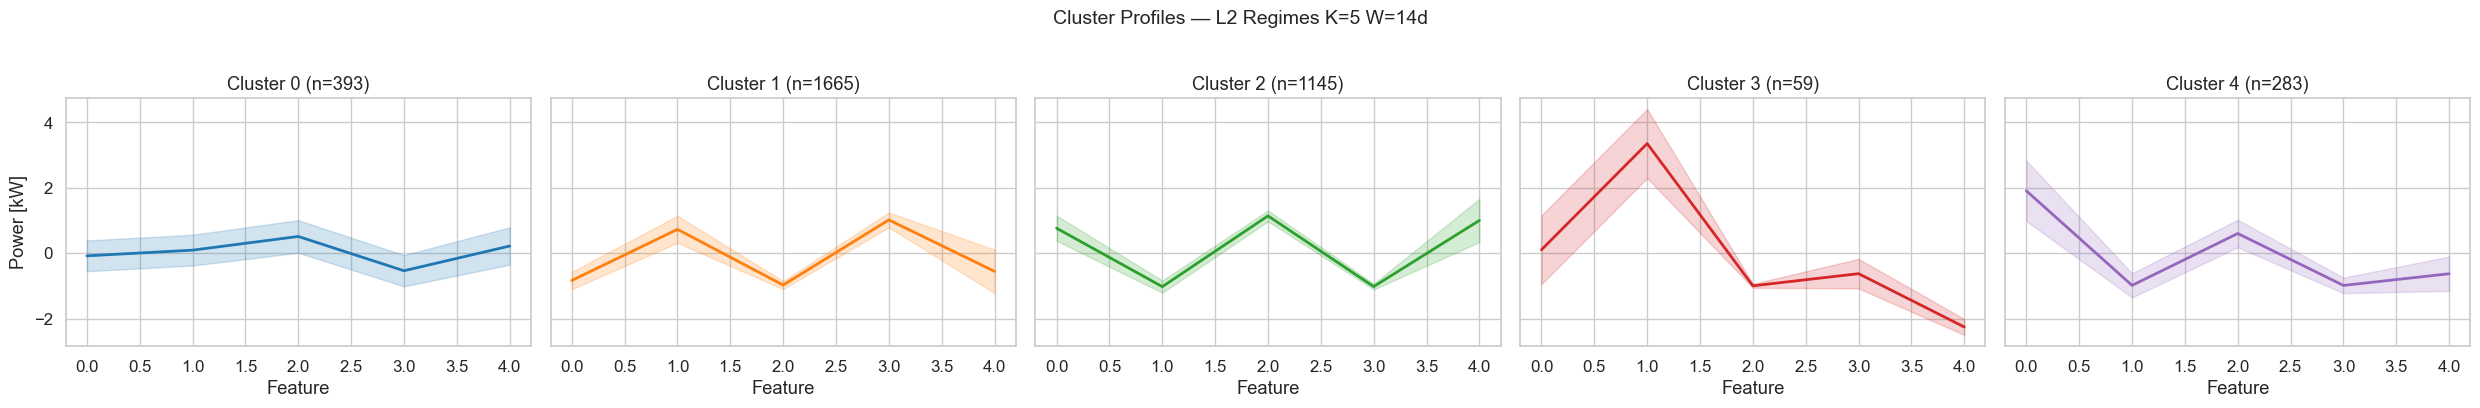

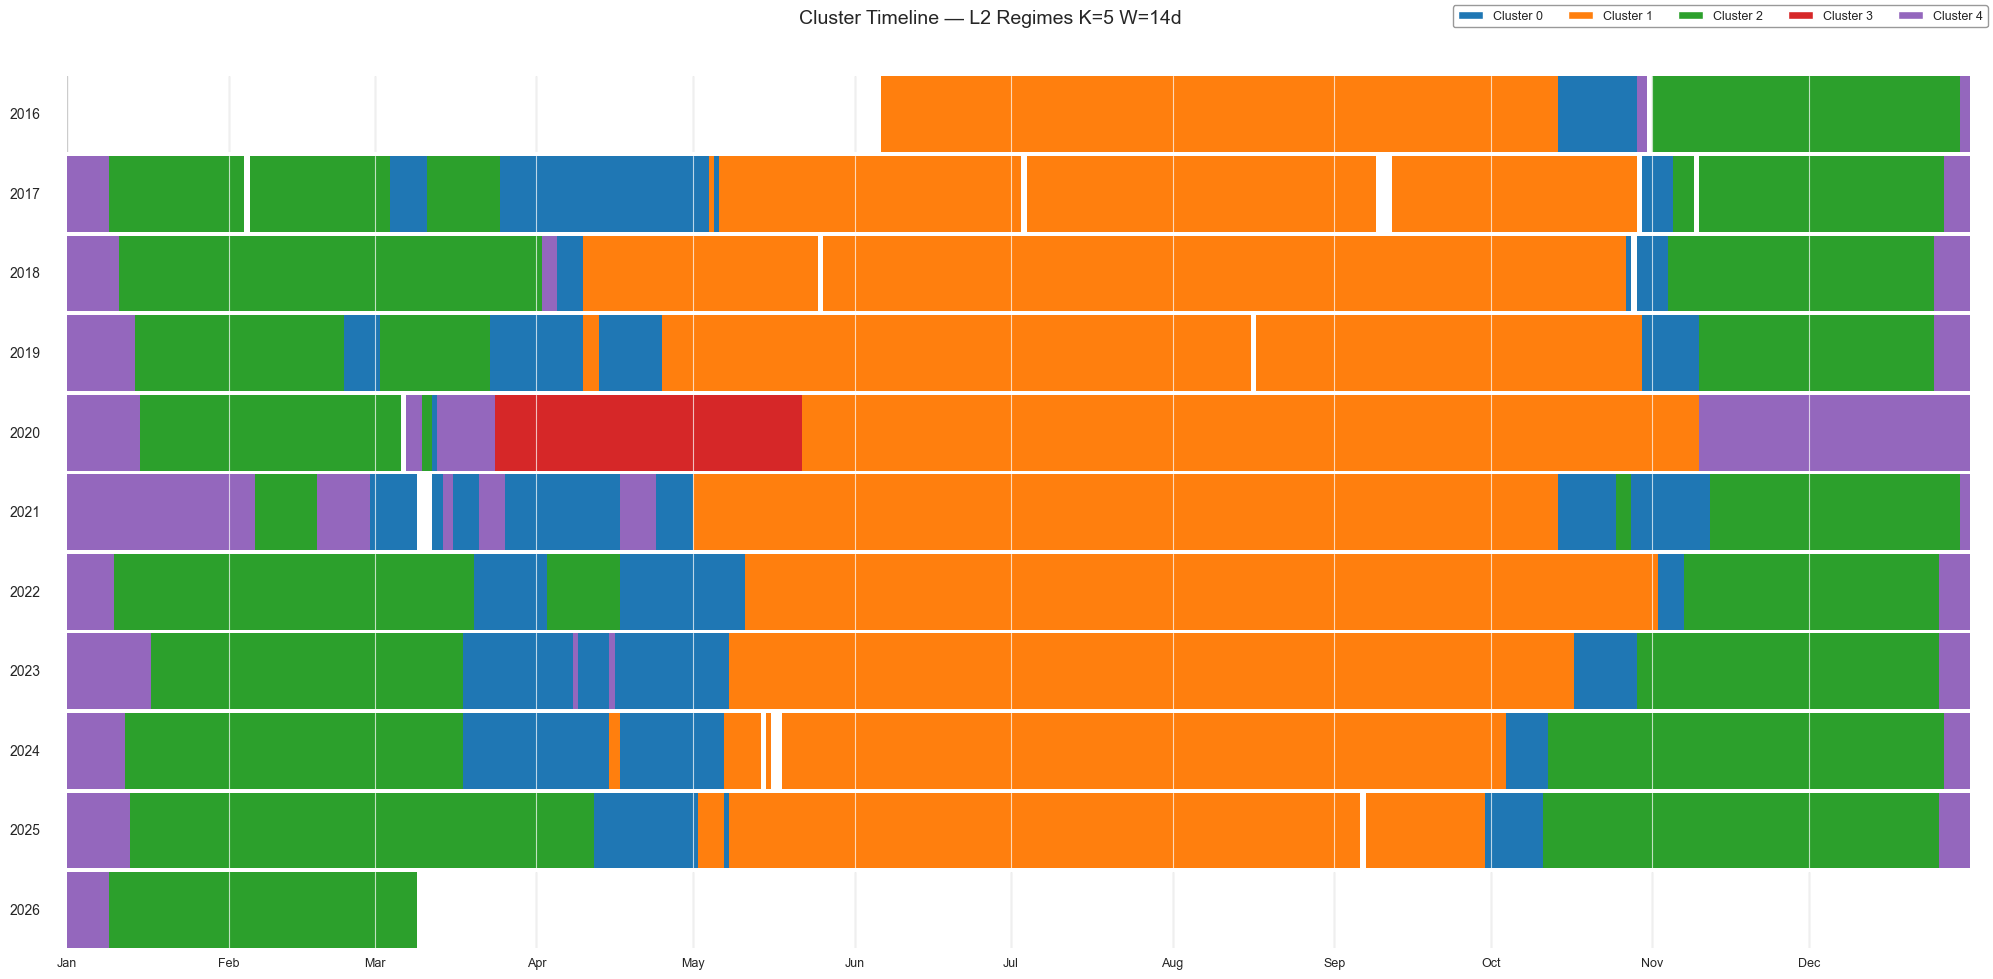

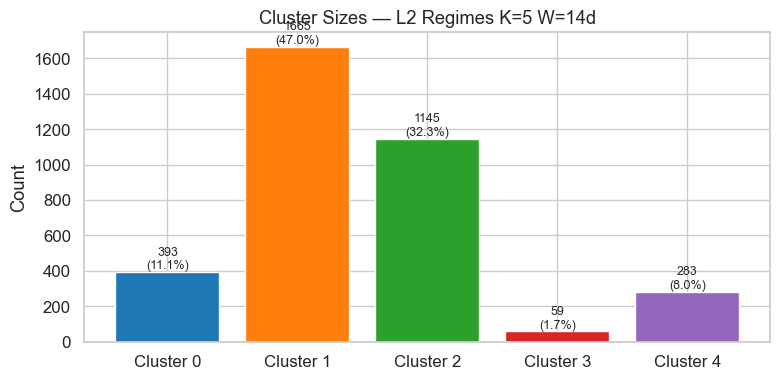

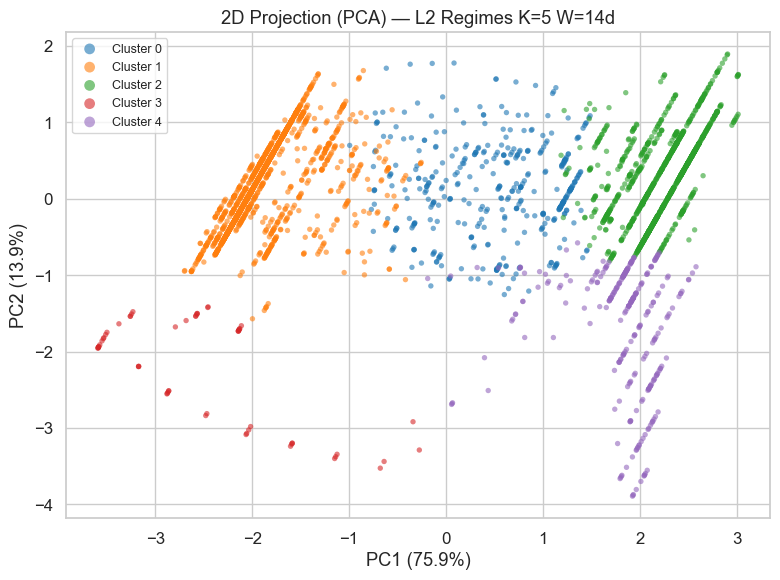

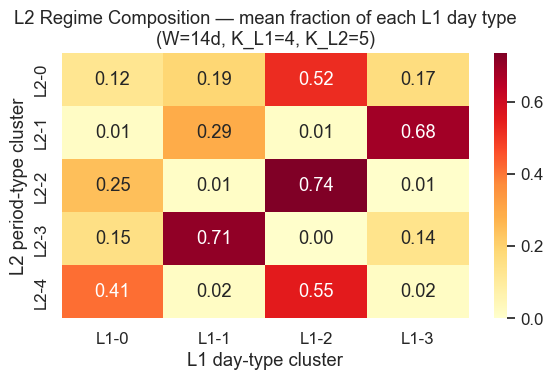

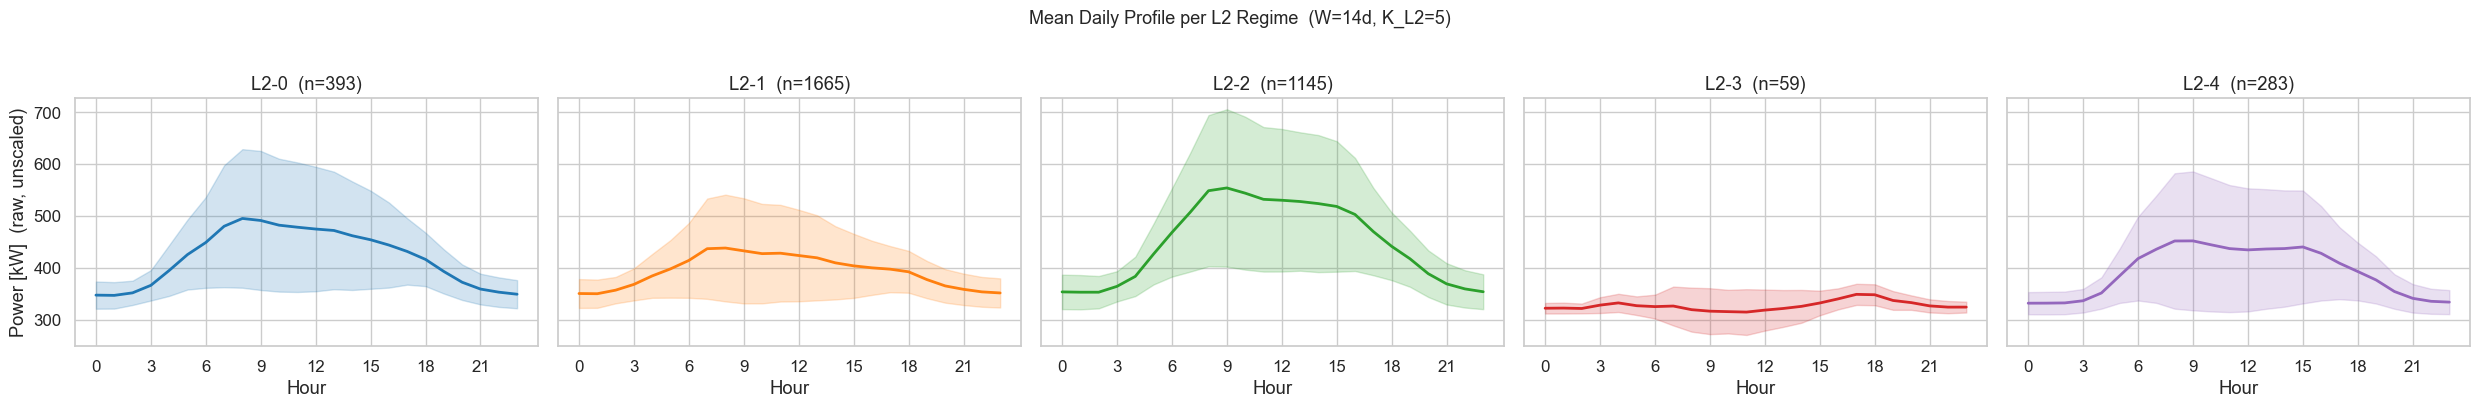

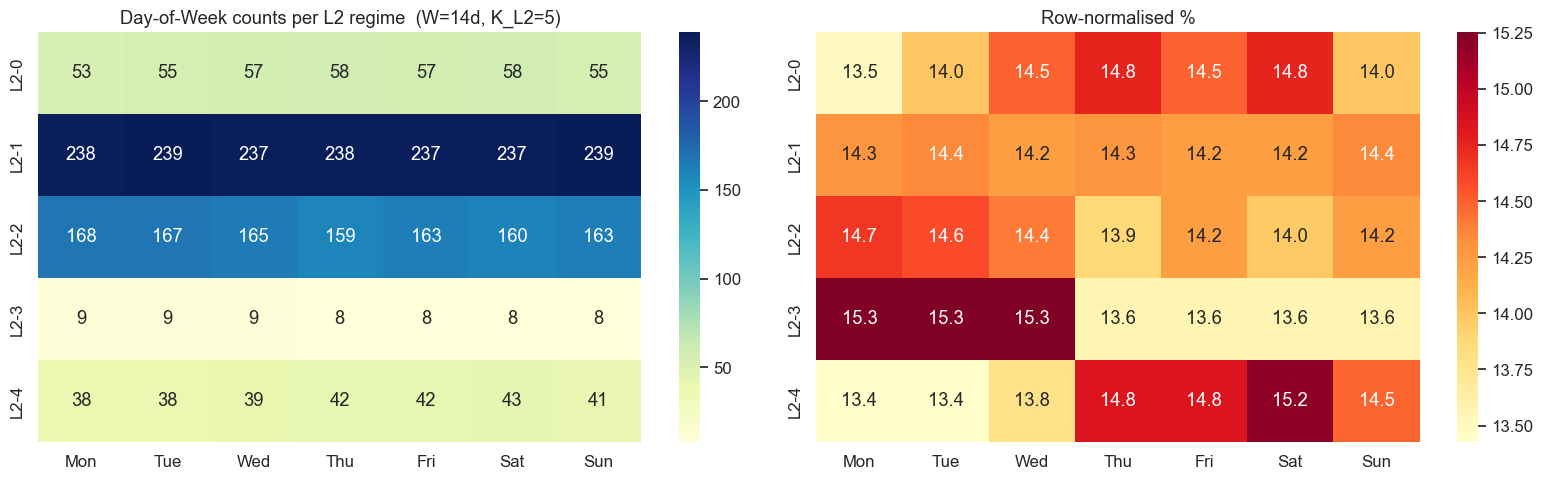

In [1]:
import sys
sys.path.insert(0, r"c:\Projects Python\Project-I\Project-I\Project_I\src")

import os
os.chdir(r"c:\Projects Python\Project-I\Project-I\Project_I")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from project_i.cluster_eval import ClusterEvaluator

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams.update({"figure.figsize": (14, 5), "figure.dpi": 100})


# ============================================================
# 1. Load & clean data
# ============================================================

df = pd.read_csv("data/clean_energy_data.csv", index_col="timestamp")
df.index = pd.to_datetime(df.index, utc=True)

p999 = df["main_meter_power_kw"].quantile(0.999)
df["main_meter_clean_kw"] = df["main_meter_power_kw"].clip(upper=p999)
df["solar_irradiance_clean"] = df["solar_irradiance_wm2"].clip(lower=0)

hourly_power  = df["main_meter_clean_kw"].resample("h").mean()
hourly_solar  = df["solar_irradiance_clean"].resample("h").mean()
hourly_temp   = df["temp_c"].resample("h").mean()
hourly_motors = df["motors_power_kw"].resample("h").mean()

print(f"Hourly power: {len(hourly_power)} rows, {hourly_power.isna().mean():.1%} missing")


# ============================================================
# 2. Daily profiles (24-dim, per-day normalized)
#    — same as notebook 03, Mode D pipeline
# ============================================================

hourly_df = hourly_power.to_frame()
hourly_df["day"]  = hourly_power.index.normalize()
hourly_df["hour"] = hourly_power.index.hour

daily_pivot = hourly_df.pivot_table(
    index="day", columns="hour", values="main_meter_clean_kw", aggfunc="mean"
)
valid_hours = daily_pivot.notna().sum(axis=1)
daily_pivot = daily_pivot[valid_hours >= 18]
daily_pivot = daily_pivot.interpolate(axis=1, limit=3).dropna()

raw_values  = daily_pivot.values.copy()          # unscaled — kept for visualisations
dates_daily = pd.DatetimeIndex(daily_pivot.index)

# Per-day z-score (removes level, keeps shape)
row_means = raw_values.mean(axis=1, keepdims=True)
row_stds  = raw_values.std(axis=1, keepdims=True)
row_stds[row_stds == 0] = 1
X_perday = (raw_values - row_means) / row_stds

print(f"Daily profiles: {len(dates_daily)} days")


# ============================================================
# 3. Mode D context features
#    (DOW sin/cos, month sin/cos, temp, solar, motors, rolling lags)
# ============================================================

daily_meta = pd.DataFrame(index=dates_daily)

dow   = dates_daily.dayofweek
month = dates_daily.month
daily_meta["dow_sin"]   = np.sin(2 * np.pi * dow   / 7)
daily_meta["dow_cos"]   = np.cos(2 * np.pi * dow   / 7)
daily_meta["month_sin"] = np.sin(2 * np.pi * month / 12)
daily_meta["month_cos"] = np.cos(2 * np.pi * month / 12)

daily_meta["temp_mean"]   = hourly_temp.resample("D").mean().reindex(dates_daily).values
daily_meta["solar_total"] = hourly_solar.resample("D").sum().reindex(dates_daily).values
daily_meta["motors_mean"] = hourly_motors.resample("D").mean().reindex(dates_daily).values

# Rolling lags: mean power and temp over prior 1 / 7 / 30 days
power_daily = pd.Series(raw_values.mean(axis=1), index=dates_daily)
temp_daily  = pd.Series(daily_meta["temp_mean"].values, index=dates_daily)

for lag in [1, 7, 30]:
    daily_meta[f"power_lag{lag}d"] = (
        power_daily.shift(1).rolling(lag, min_periods=1).mean().values
    )
    daily_meta[f"temp_lag{lag}d"] = (
        temp_daily.shift(1).rolling(lag, min_periods=1).mean().values
    )

# Drop first 30 days (rolling lags warm-up)
WARMUP = 30
X_shape   = X_perday[WARMUP:]
raw_vals  = raw_values[WARMUP:]
dates_D   = dates_daily[WARMUP:]
meta_D    = daily_meta.iloc[WARMUP:].copy()

# Fill sparse columns (temp is 75% missing) with column median before scaling
meta_D = meta_D.fillna(meta_D.median())

scaler_meta = StandardScaler()
meta_scaled = scaler_meta.fit_transform(meta_D.values)

X_D = np.hstack([X_shape, meta_scaled])
print(f"Mode D feature matrix: {X_D.shape}")


# ============================================================
# 4. PCA reduction
# ============================================================

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_D)
print(f"PCA: {X_D.shape[1]} → {X_pca.shape[1]} dims  "
      f"({pca.explained_variance_ratio_.sum():.1%} variance explained)")


# ============================================================
# 5. L1 Clustering — K selection
# ============================================================

print("\n--- L1 K selection (Mode D, per-day norm) ---")
ClusterEvaluator.plot_k_selection(X_pca, k_range=range(2, 10), name="L1 Daily (Mode D)")


# ============================================================
# 6. L1 Clustering — fit
#    Inspect plots above, then set K_L1
# ============================================================

K_L1 = 4   # <-- adjust after inspecting L1 K selection plots

km_l1    = KMeans(n_clusters=K_L1, n_init=20, random_state=42)
labels_l1 = km_l1.fit_predict(X_pca)

eval_l1 = ClusterEvaluator(X_pca, labels_l1, dates_D, name=f"L1 Daily K={K_L1}")
eval_l1.plot_all()


# ============================================================
# 7. L2 Feature matrix — rolling window histogram
#
#    For each day d, look back W days and compute:
#      - normalised histogram of L1 labels  →  K_L1 dims
#      - rolling mean raw consumption       →  1 dim   (adds level/season signal)
#
#    One L2 observation per day (rolling step = 1).
# ============================================================

def build_l2_features(labels, dates, raw_daily_power, window_sizes, k_l1):
    """Return dict: W -> (X_l2_scaled, dates_l2, X_l2_raw)."""
    labels_arr = np.asarray(labels)
    power_arr  = np.asarray(raw_daily_power)
    results    = {}

    for W in window_sizes:
        rows, idx = [], []
        for d in range(W - 1, len(labels_arr)):
            hist  = np.bincount(labels_arr[d - W + 1: d + 1], minlength=k_l1) / W
            pmean = np.nanmean(power_arr[d - W + 1: d + 1])
            rows.append(np.append(hist, pmean))
            idx.append(dates[d])

        X_raw = np.array(rows)
        X_scaled = StandardScaler().fit_transform(X_raw)
        results[W] = (X_scaled, pd.DatetimeIndex(idx), X_raw)
        print(f"  W={W:>2}d: {X_raw.shape[0]} observations, {X_raw.shape[1]} features "
              f"({k_l1} histogram bins + 1 power mean)")

    return results


raw_daily_power = raw_vals.mean(axis=1)

print("\n--- Building L2 feature matrices ---")
l2_data = build_l2_features(
    labels_l1, dates_D, raw_daily_power,
    window_sizes=[7, 14, 28],
    k_l1=K_L1,
)


# ============================================================
# 8. L2 K selection — one plot per window size
# ============================================================

for W, (X_l2, dates_l2, _) in l2_data.items():
    print(f"\n--- L2 K selection (W={W}d) ---")
    ClusterEvaluator.plot_k_selection(X_l2, k_range=range(2, 12), name=f"L2 Regimes W={W}d")


# ============================================================
# 9. L2 Clustering — fit
#    Inspect plots above, then set W_L2 and K_L2
# ============================================================

W_L2 = 14   # <-- choose window size after inspecting K selection plots
K_L2 = 5    # <-- choose K after inspecting K selection plots

X_l2, dates_l2, X_l2_raw = l2_data[W_L2]

km_l2    = KMeans(n_clusters=K_L2, n_init=20, random_state=42)
labels_l2 = km_l2.fit_predict(X_l2)

eval_l2 = ClusterEvaluator(X_l2, labels_l2, dates_l2,
                            name=f"L2 Regimes K={K_L2} W={W_L2}d")
eval_l2.plot_all()


# ============================================================
# 10. Composition heatmap
#     Rows = L2 cluster, Cols = L1 day type
#     Values = mean fraction of that L1 type inside each L2 regime
# ============================================================

hist_cols = [f"L1-{c}" for c in range(K_L1)]
comp_df   = pd.DataFrame(X_l2_raw[:, :K_L1], columns=hist_cols)
comp_df["L2"] = labels_l2

mean_comp = comp_df.groupby("L2")[hist_cols].mean()

fig, ax = plt.subplots(figsize=(max(6, K_L1 * 1.5), max(4, K_L2 * 0.8)))
sns.heatmap(
    mean_comp, annot=True, fmt=".2f", cmap="YlOrRd",
    xticklabels=hist_cols,
    yticklabels=[f"L2-{c}" for c in mean_comp.index],
    vmin=0, ax=ax,
)
ax.set_title(
    f"L2 Regime Composition — mean fraction of each L1 day type\n"
    f"(W={W_L2}d, K_L1={K_L1}, K_L2={K_L2})"
)
ax.set_xlabel("L1 day-type cluster")
ax.set_ylabel("L2 period-type cluster")
plt.tight_layout()
plt.show()


# ============================================================
# 11. Mean raw daily profiles per L2 regime
#     (shows what a typical day actually looks like in each regime)
# ============================================================

# Map window-endpoint dates → row index in dates_D
date_to_idx = {d: i for i, d in enumerate(dates_D)}
win_end_idx = np.array([date_to_idx[d] for d in dates_l2])

X_profiles_for_l2 = raw_vals[win_end_idx]   # shape: (n_l2_obs, 24)

l2_clusters  = sorted(np.unique(labels_l2))
base_colors  = plt.cm.tab10(np.linspace(0, 1, max(len(l2_clusters), 10)))
color_map_l2 = {c: base_colors[i] for i, c in enumerate(l2_clusters)}

fig, axes = plt.subplots(
    1, len(l2_clusters),
    figsize=(5 * len(l2_clusters), 4),
    sharey=True, squeeze=False,
)
axes = axes.flatten()
hours = np.arange(24)

for ax, c in zip(axes, l2_clusters):
    mask    = labels_l2 == c
    profiles = X_profiles_for_l2[mask]
    mean_p  = profiles.mean(axis=0)
    std_p   = profiles.std(axis=0)
    ax.plot(hours, mean_p, color=color_map_l2[c], linewidth=2)
    ax.fill_between(hours, mean_p - std_p, mean_p + std_p,
                    alpha=0.2, color=color_map_l2[c])
    ax.set_title(f"L2-{c}  (n={mask.sum()})")
    ax.set_xlabel("Hour")
    ax.set_xticks(range(0, 24, 3))

axes[0].set_ylabel("Power [kW]  (raw, unscaled)")
plt.suptitle(
    f"Mean Daily Profile per L2 Regime  (W={W_L2}d, K_L2={K_L2})",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()


# ============================================================
# 12. Day-of-week breakdown per L2 regime
# ============================================================

dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_l2    = dates_l2.dayofweek

contingency = pd.DataFrame(
    np.zeros((K_L2, 7), dtype=int),
    index=[f"L2-{c}" for c in range(K_L2)],
    columns=dow_names,
)
for label, d in zip(labels_l2, dow_l2):
    contingency.iloc[label, d] += 1

contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(contingency,     annot=True, fmt="d",   cmap="YlGnBu", ax=ax1)
sns.heatmap(contingency_pct, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax2)
ax1.set_title(f"Day-of-Week counts per L2 regime  (W={W_L2}d, K_L2={K_L2})")
ax2.set_title("Row-normalised %")
for ax in (ax1, ax2):
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


  L2 Regimes K=7 W=14d — K=7
  Silhouette score:       0.3993
  Calinski-Harabasz:      4556.4
  Davies-Bouldin:         0.8630

  Per-cluster breakdown:
   Cluster   Size       %  Silhouette
  -----------------------------------
         0    660   18.6%     0.3876
         1    980   27.6%     0.4815
         2    379   10.7%     0.1730
         3     58    1.6%     0.4172
         4    133    3.8%     0.4427
         5    639   18.0%     0.4417
         6    696   19.6%     0.3691



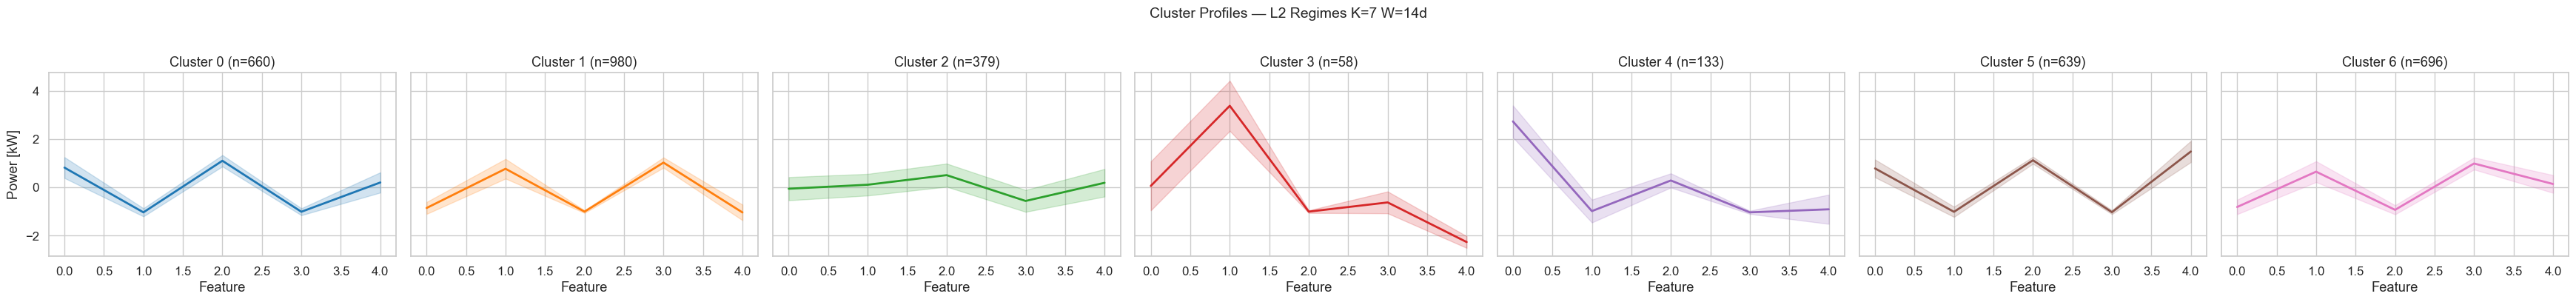

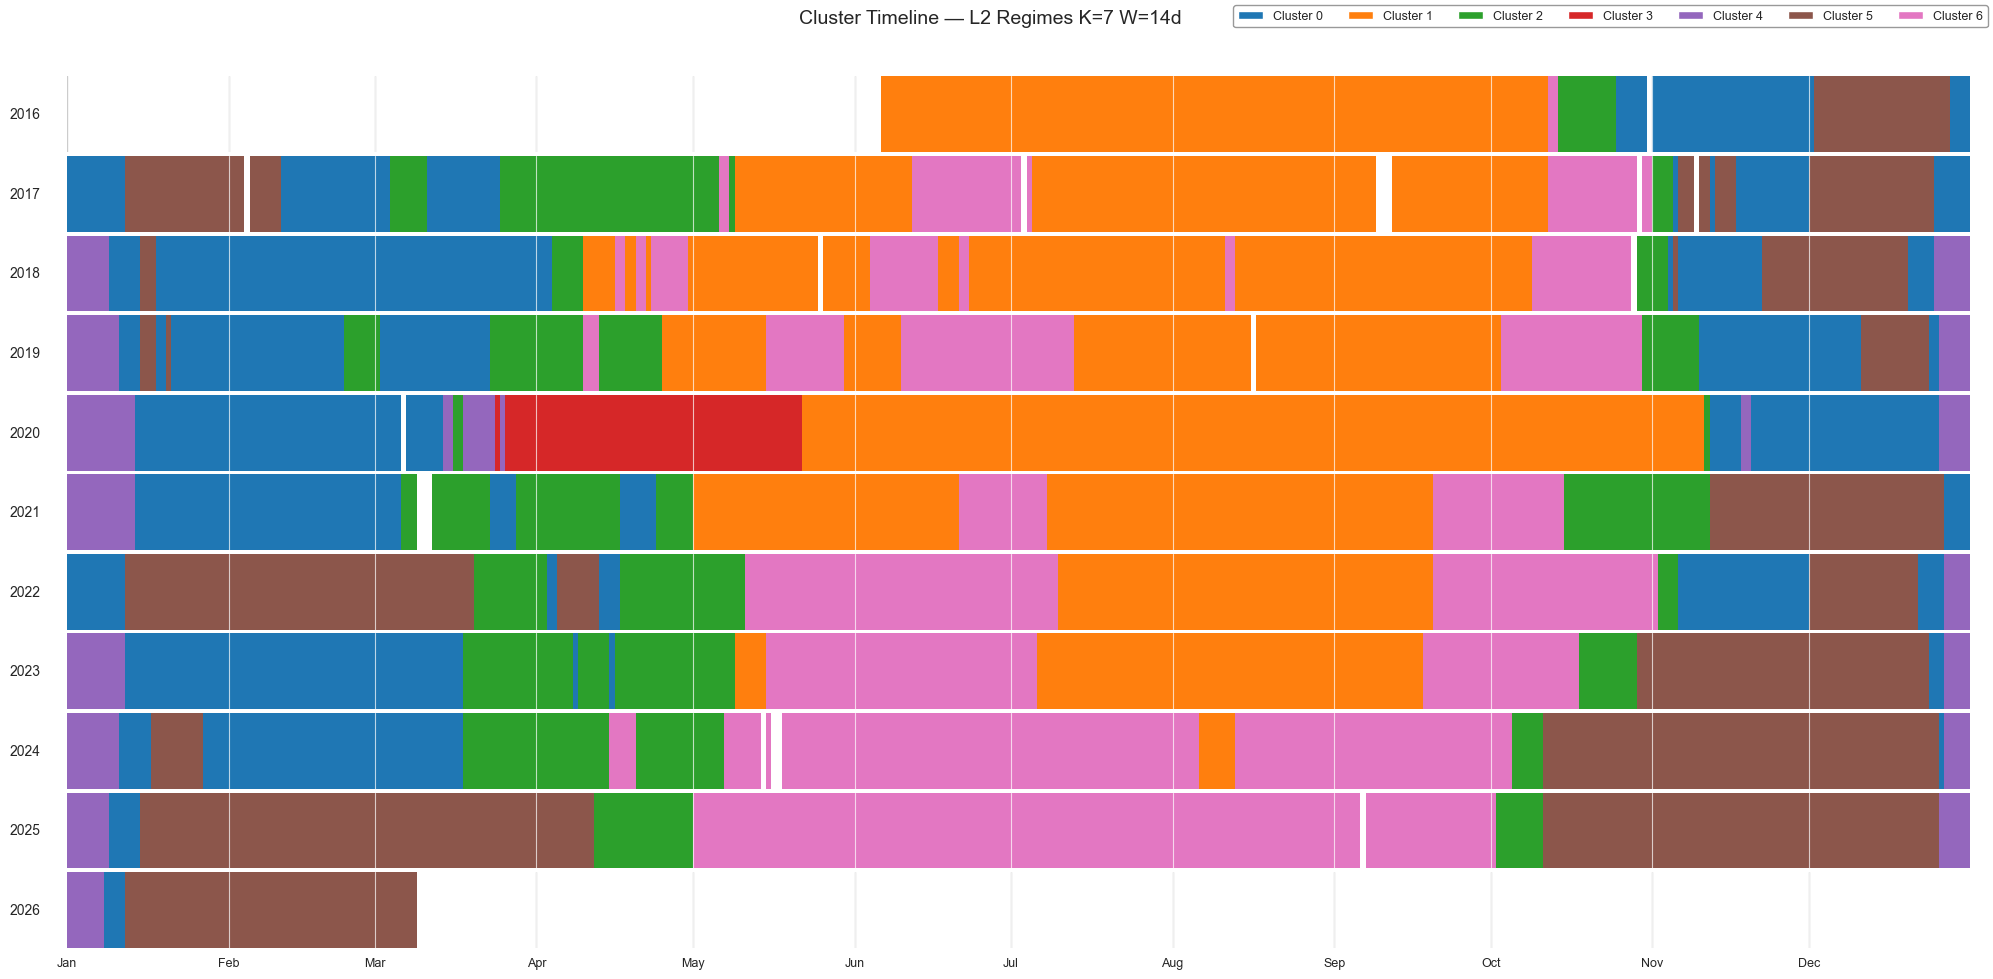

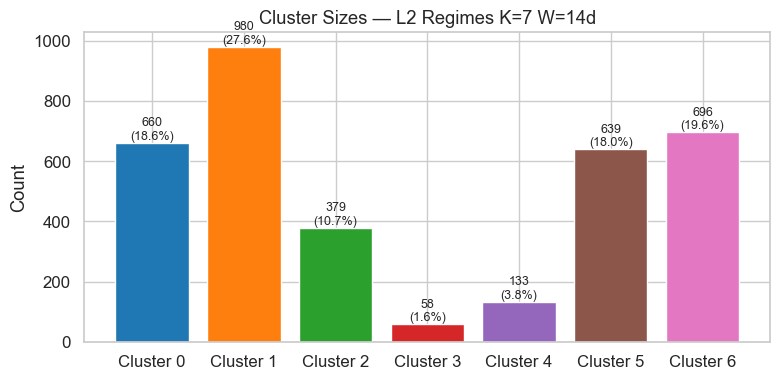

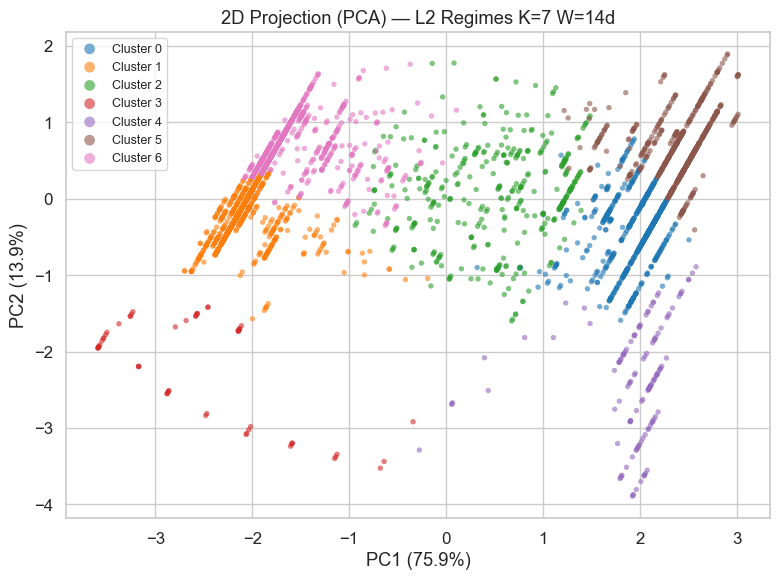

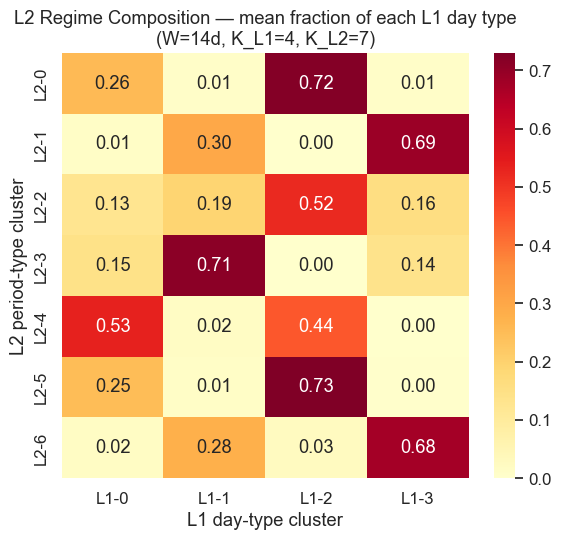

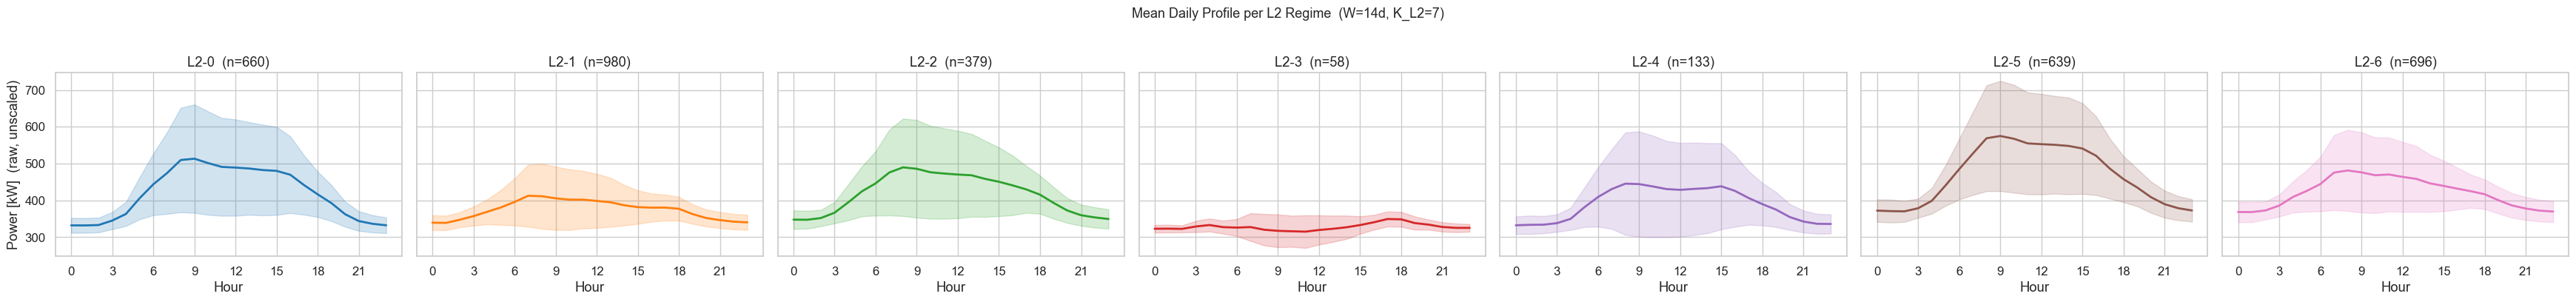

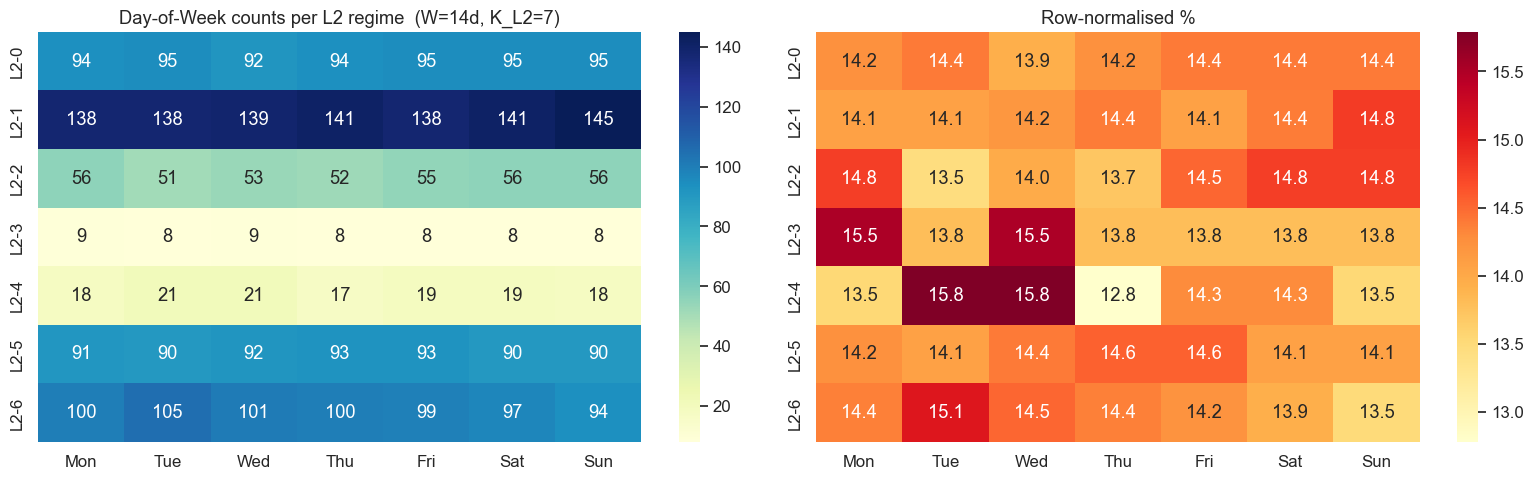

In [2]:
W_L2 = 14   # <-- choose window size after inspecting K selection plots
K_L2 = 7    # <-- choose K after inspecting K selection plots

X_l2, dates_l2, X_l2_raw = l2_data[W_L2]

km_l2    = KMeans(n_clusters=K_L2, n_init=20, random_state=42)
labels_l2 = km_l2.fit_predict(X_l2)

eval_l2 = ClusterEvaluator(X_l2, labels_l2, dates_l2,
                            name=f"L2 Regimes K={K_L2} W={W_L2}d")
eval_l2.plot_all()


# ============================================================
# 10. Composition heatmap
#     Rows = L2 cluster, Cols = L1 day type
#     Values = mean fraction of that L1 type inside each L2 regime
# ============================================================

hist_cols = [f"L1-{c}" for c in range(K_L1)]
comp_df   = pd.DataFrame(X_l2_raw[:, :K_L1], columns=hist_cols)
comp_df["L2"] = labels_l2

mean_comp = comp_df.groupby("L2")[hist_cols].mean()

fig, ax = plt.subplots(figsize=(max(6, K_L1 * 1.5), max(4, K_L2 * 0.8)))
sns.heatmap(
    mean_comp, annot=True, fmt=".2f", cmap="YlOrRd",
    xticklabels=hist_cols,
    yticklabels=[f"L2-{c}" for c in mean_comp.index],
    vmin=0, ax=ax,
)
ax.set_title(
    f"L2 Regime Composition — mean fraction of each L1 day type\n"
    f"(W={W_L2}d, K_L1={K_L1}, K_L2={K_L2})"
)
ax.set_xlabel("L1 day-type cluster")
ax.set_ylabel("L2 period-type cluster")
plt.tight_layout()
plt.show()


# ============================================================
# 11. Mean raw daily profiles per L2 regime
#     (shows what a typical day actually looks like in each regime)
# ============================================================

# Map window-endpoint dates → row index in dates_D
date_to_idx = {d: i for i, d in enumerate(dates_D)}
win_end_idx = np.array([date_to_idx[d] for d in dates_l2])

X_profiles_for_l2 = raw_vals[win_end_idx]   # shape: (n_l2_obs, 24)

l2_clusters  = sorted(np.unique(labels_l2))
base_colors  = plt.cm.tab10(np.linspace(0, 1, max(len(l2_clusters), 10)))
color_map_l2 = {c: base_colors[i] for i, c in enumerate(l2_clusters)}

fig, axes = plt.subplots(
    1, len(l2_clusters),
    figsize=(5 * len(l2_clusters), 4),
    sharey=True, squeeze=False,
)
axes = axes.flatten()
hours = np.arange(24)

for ax, c in zip(axes, l2_clusters):
    mask    = labels_l2 == c
    profiles = X_profiles_for_l2[mask]
    mean_p  = profiles.mean(axis=0)
    std_p   = profiles.std(axis=0)
    ax.plot(hours, mean_p, color=color_map_l2[c], linewidth=2)
    ax.fill_between(hours, mean_p - std_p, mean_p + std_p,
                    alpha=0.2, color=color_map_l2[c])
    ax.set_title(f"L2-{c}  (n={mask.sum()})")
    ax.set_xlabel("Hour")
    ax.set_xticks(range(0, 24, 3))

axes[0].set_ylabel("Power [kW]  (raw, unscaled)")
plt.suptitle(
    f"Mean Daily Profile per L2 Regime  (W={W_L2}d, K_L2={K_L2})",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()


# ============================================================
# 12. Day-of-week breakdown per L2 regime
# ============================================================

dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_l2    = dates_l2.dayofweek

contingency = pd.DataFrame(
    np.zeros((K_L2, 7), dtype=int),
    index=[f"L2-{c}" for c in range(K_L2)],
    columns=dow_names,
)
for label, d in zip(labels_l2, dow_l2):
    contingency.iloc[label, d] += 1

contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(contingency,     annot=True, fmt="d",   cmap="YlGnBu", ax=ax1)
sns.heatmap(contingency_pct, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax2)
ax1.set_title(f"Day-of-Week counts per L2 regime  (W={W_L2}d, K_L2={K_L2})")
ax2.set_title("Row-normalised %")
for ax in (ax1, ax2):
    ax.set_ylabel("")
plt.tight_layout()
plt.show()